In [2]:
import pandas as pd
df = pd.read_csv("titanic.csv")
print(df.shape)
df.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Missing,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Missing,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Missing,Southampton,no,True


In [3]:
from sklearn.model_selection import train_test_split
numeric_features = ["pclass", "age", "sibsp", "parch", "fare"]
categorical_features = ["sex", "embarked"]
X = df[numeric_features + categorical_features]
y = df["survived"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("\nTraining class balance:")
print(y_train.value_counts(normalize=True))
print("\nTesting class balance:")
print(y_test.value_counts(normalize=True))

Training shape: (712, 7)
Testing shape: (179, 7)

Training class balance:
survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

Testing class balance:
survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))])
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)])
print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42)}
pipelines = {}
for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)])
    pipe.fit(X_train, y_train)
    pipelines[name] = pipe
    print(name, "trained successfully!")

Logistic Regression trained successfully!
Decision Tree trained successfully!
Random Forest trained successfully!


In [6]:
predictions = {}
for name, pipe in pipelines.items():
    predictions[name] = pipe.predict(X_test)
print("Predictions completed!")

Predictions completed!


In [7]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix)
results = []
for name, pipe in pipelines.items():
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob)})
results_df = pd.DataFrame(results)
print(results_df.round(4))

                 Model  Accuracy  Precision  Recall      F1     AUC
0  Logistic Regression    0.8045     0.7931  0.6667  0.7244  0.8445
1        Decision Tree    0.8268     0.8065  0.7246  0.7634  0.8054
2        Random Forest    0.8268     0.8167  0.7101  0.7597  0.8314


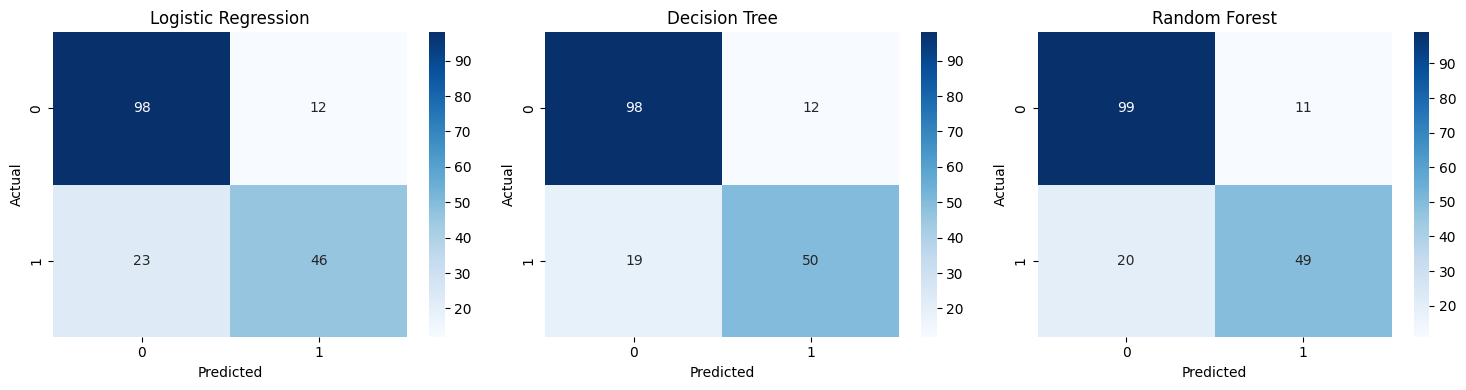

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pipe) in zip(axes, pipelines.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

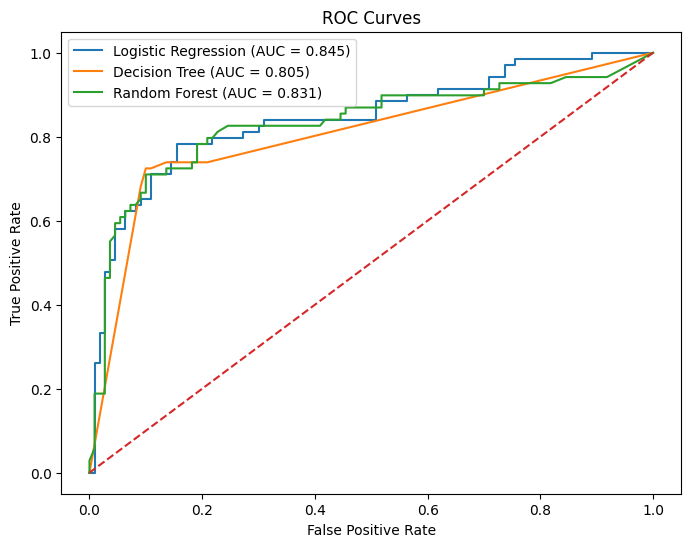

In [9]:
from sklearn.metrics import roc_curve
plt.figure(figsize=(8, 6))
for name, pipe in pipelines.items():
    y_prob = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

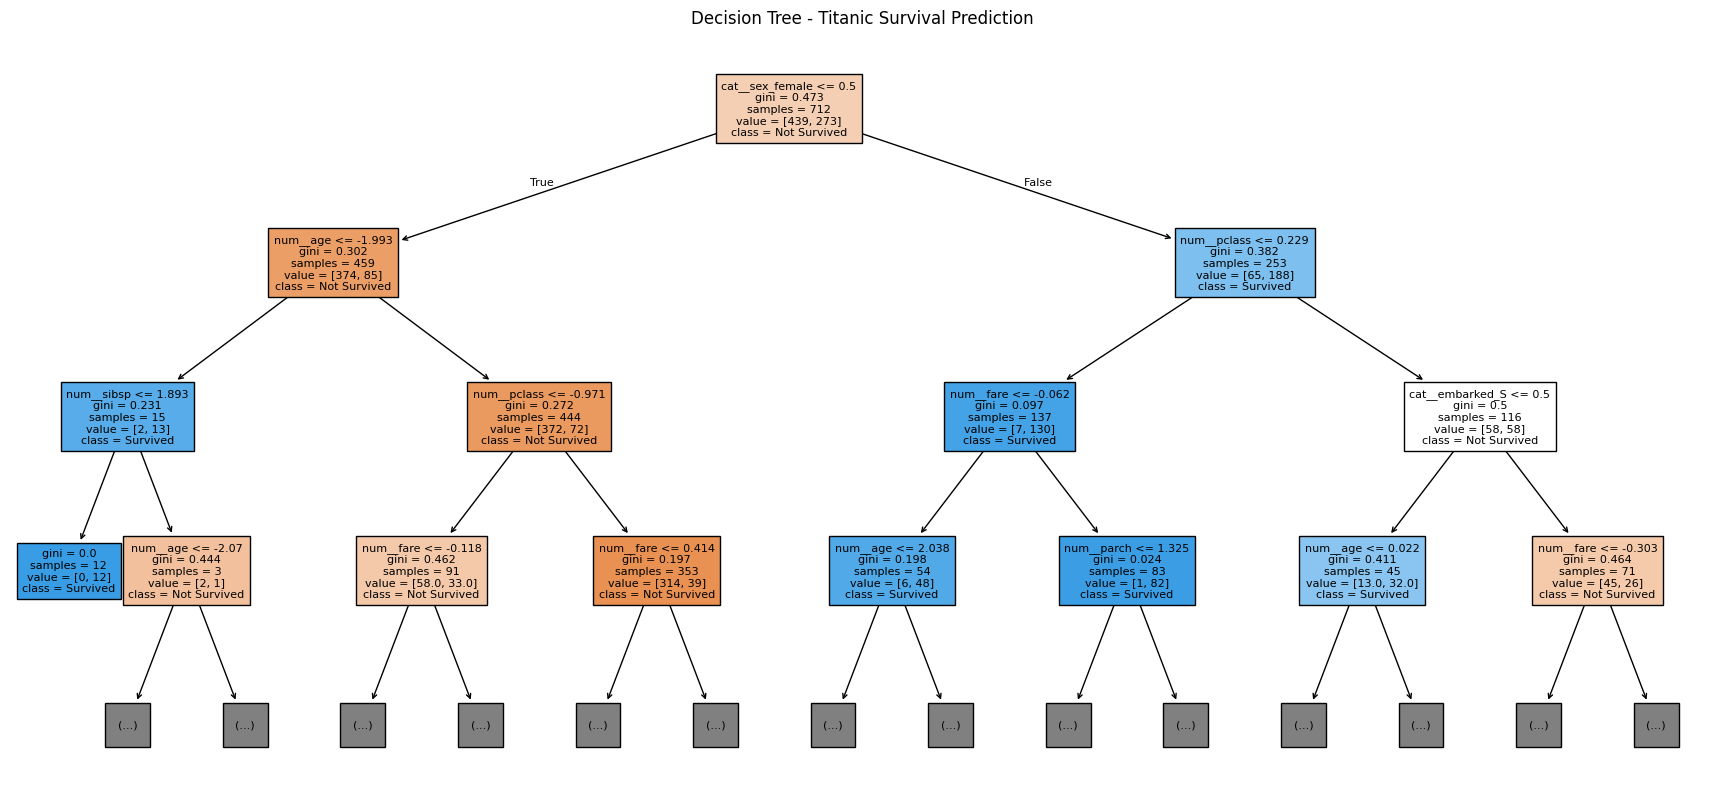

In [10]:
from sklearn.tree import plot_tree
tree_pipeline = pipelines["Decision Tree"]
fitted_preprocessor = tree_pipeline.named_steps["preprocessor"]
feature_names = fitted_preprocessor.get_feature_names_out()
tree_model = tree_pipeline.named_steps["model"]
plt.figure(figsize=(22, 10))
plot_tree(tree_model,feature_names=feature_names,class_names=["Not Survived", "Survived"],filled=True,max_depth=3,fontsize=8)
plt.title("Decision Tree - Titanic Survival Prediction")
plt.show()

In [11]:
print("Overall class balance:")
print(y.value_counts())
print("\nClass proportions:")
print(y.value_counts(normalize=True))

Overall class balance:
survived
0    549
1    342
Name: count, dtype: int64

Class proportions:
survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [12]:
pip install imblearn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
baseline_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))])
baseline_pipeline.fit(X_train, y_train)
baseline_pred = baseline_pipeline.predict(X_test)
balanced_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42))])
balanced_pipeline.fit(X_train, y_train)
balanced_pred = balanced_pipeline.predict(X_test)
smote_pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42))])

smote_pipeline.fit(X_train, y_train)
smote_pred = smote_pipeline.predict(X_test)
print("All three approaches trained successfully!")

All three approaches trained successfully!


In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score
imbalance_results = pd.DataFrame({
    "Method": [
        "Baseline",
        "Class Weight Balanced",
        "SMOTE"],
    "Precision": [
        precision_score(y_test, baseline_pred),
        precision_score(y_test, balanced_pred),
        precision_score(y_test, smote_pred)],
    "Recall": [
        recall_score(y_test, baseline_pred),
        recall_score(y_test, balanced_pred),
        recall_score(y_test, smote_pred)],
    "F1": [
        f1_score(y_test, baseline_pred),
        f1_score(y_test, balanced_pred),
        f1_score(y_test, smote_pred)]})
print(imbalance_results.round(4))

                  Method  Precision  Recall      F1
0               Baseline     0.7931  0.6667  0.7244
1  Class Weight Balanced     0.7297  0.7826  0.7552
2                  SMOTE     0.7397  0.7826  0.7606


In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        oob_score=True,
        random_state=42,
        bootstrap=True))])
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10],
    "model__max_features": ["sqrt", "log2"]}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1:")
print(grid_search.best_score_)

Best Parameters:
{'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__n_estimators': 100}

Best Cross-Validation F1:
0.7452284893229187


In [16]:
best_rf_pipeline = grid_search.best_estimator_

best_rf_model = best_rf_pipeline.named_steps["model"]

print("Best Random Forest OOB Score:")
print(best_rf_model.oob_score_)

Best Random Forest OOB Score:
0.8061797752808989


In [17]:
RandomForestClassifier(oob_score=True)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

best_rf_pred = best_rf_pipeline.predict(X_test)
best_rf_prob = best_rf_pipeline.predict_proba(X_test)[:, 1]

print("Tuned Random Forest Results")
print("---------------------------")
print("Accuracy :", accuracy_score(y_test, best_rf_pred))
print("Precision:", precision_score(y_test, best_rf_pred))
print("Recall   :", recall_score(y_test, best_rf_pred))
print("F1 Score :", f1_score(y_test, best_rf_pred))
print("AUC      :", roc_auc_score(y_test, best_rf_prob))
print("OOB Score:", best_rf_model.oob_score_)

Tuned Random Forest Results
---------------------------
Accuracy : 0.8212290502793296
Precision: 0.8245614035087719
Recall   : 0.6811594202898551
F1 Score : 0.746031746031746
AUC      : 0.8424242424242424
OOB Score: 0.8061797752808989


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Features used to predict fare
reg_numeric = ["pclass", "age", "sibsp", "parch", "survived"]
reg_categorical = ["sex", "embarked"]

X_reg = df[reg_numeric + reg_categorical]
y_reg = df["fare"]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

print("Regression training shape:", X_reg_train.shape)
print("Regression testing shape:", X_reg_test.shape)

Regression training shape: (712, 7)
Regression testing shape: (179, 7)


In [20]:
reg_numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

reg_categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

reg_preprocessor = ColumnTransformer([
    ("num", reg_numeric_transformer, reg_numeric),
    ("cat", reg_categorical_transformer, reg_categorical)
])

In [21]:
regression_pipeline = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("model", LinearRegression())
])

regression_pipeline.fit(X_reg_train, y_reg_train)

fare_pred = regression_pipeline.predict(X_reg_test)

print("Linear Regression trained successfully!")

Linear Regression trained successfully!


In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_reg_test, fare_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, fare_pred))
r2 = r2_score(y_reg_test, fare_pred)
X_reg_test_transformed = regression_pipeline.named_steps[
    "preprocessor"
].transform(X_reg_test)

n = len(y_reg_test)
p = X_reg_test_transformed.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("Regression Results")
print("------------------")
print("MAE        :", round(mae, 4))
print("RMSE       :", round(rmse, 4))
print("R²         :", round(r2, 4))
print("Adjusted R²:", round(adjusted_r2, 4))

Regression Results
------------------
MAE        : 20.8977
RMSE       : 30.5328
R²         : 0.3975
Adjusted R²: 0.3617


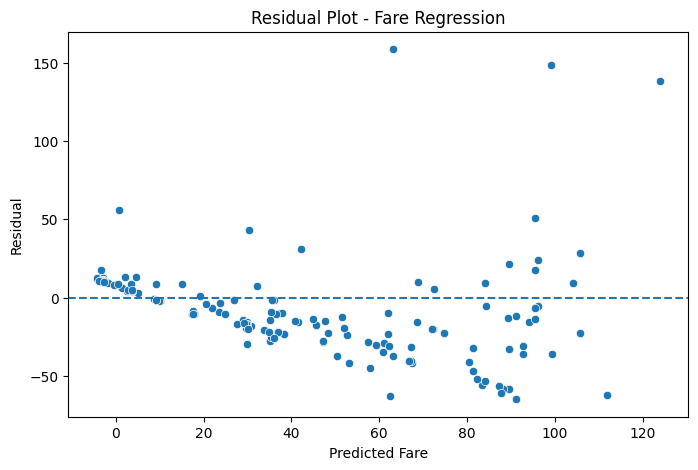

In [23]:
residuals = y_reg_test - fare_pred

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=fare_pred,
    y=residuals
)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Fare")
plt.ylabel("Residual")
plt.title("Residual Plot - Fare Regression")

plt.show()

In [24]:
tuned_result = {
    "Model": "Tuned Random Forest",
    "Accuracy": accuracy_score(y_test, best_rf_pred),
    "Precision": precision_score(y_test, best_rf_pred),
    "Recall": recall_score(y_test, best_rf_pred),
    "F1": f1_score(y_test, best_rf_pred),
    "AUC": roc_auc_score(y_test, best_rf_prob)
}
final_classification_results = pd.concat(
    [results_df,pd.DataFrame([tuned_result])],ignore_index=True)
print(final_classification_results.round(4))

                 Model  Accuracy  Precision  Recall      F1     AUC
0  Logistic Regression    0.8045     0.7931  0.6667  0.7244  0.8445
1        Decision Tree    0.8268     0.8065  0.7246  0.7634  0.8054
2        Random Forest    0.8268     0.8167  0.7101  0.7597  0.8314
3  Tuned Random Forest    0.8212     0.8246  0.6812  0.7460  0.8424


In [25]:
best_model_name = final_classification_results.loc[
    final_classification_results["F1"].idxmax(),
    "Model"
]

print("Best classifier based on F1:", best_model_name)

Best classifier based on F1: Decision Tree


In [26]:
print("CLASSIFICATION METRICS")
print("======================")
display(final_classification_results.round(4))

print("\nREGRESSION METRICS")
print("==================")

regression_results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²", "Adjusted R²"],
    "Value": [mae, rmse, r2, adjusted_r2]
})

display(regression_results.round(4))

CLASSIFICATION METRICS


,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.8045,0.7931,0.6667,0.7244,0.8445
1,Decision Tree,0.8268,0.8065,0.7246,0.7634,0.8054
2,Random Forest,0.8268,0.8167,0.7101,0.7597,0.8314
3,Tuned Random Forest,0.8212,0.8246,0.6812,0.7460,0.8424



REGRESSION METRICS


,Metric,Value
0,MAE,20.8977
1,RMSE,30.5328
2,R²,0.3975
3,Adjusted R²,0.3617


In [27]:
import joblib

best_pipeline = best_rf_pipeline

joblib.dump(
    best_pipeline,
    "best_titanic_pipeline.joblib"
)

print("Pipeline saved successfully!")

Pipeline saved successfully!


In [28]:
loaded_pipeline = joblib.load(
    "best_titanic_pipeline.joblib")
raw_sample = X_test.iloc[[0]]
prediction = loaded_pipeline.predict(raw_sample)
probability = loaded_pipeline.predict_proba(raw_sample)
print("Raw input:")
display(raw_sample)
print("Prediction:", prediction)
print("Prediction probability:", probability)

Raw input:


,pclass,age,sibsp,parch,fare,sex,embarked
565,3,24.0,2,0,24.15,male,S


Prediction: [0]
Prediction probability: [[0.8165422 0.1834578]]


In [29]:
import joblib

best_pipeline = pipelines["Decision Tree"]

joblib.dump(
    best_pipeline,
    "best_titanic_pipeline.joblib"
)

print("Best pipeline saved successfully!")

Best pipeline saved successfully!


In [30]:
loaded_pipeline = joblib.load("best_titanic_pipeline.joblib")

raw_sample = X_test.iloc[[0]]

prediction = loaded_pipeline.predict(raw_sample)
probability = loaded_pipeline.predict_proba(raw_sample)

print("Raw input:")
display(raw_sample)

print("Prediction:", prediction)
print("Prediction probability:", probability)

Raw input:


,pclass,age,sibsp,parch,fare,sex,embarked
565,3,24.0,2,0,24.15,male,S


Prediction: [0]
Prediction probability: [[1. 0.]]


Among the evaluated classification models, the Decision Tree achieved the highest F1-score (0.7634) and recall (0.7246), while the Random Forest achieved the highest precision (0.8167). Logistic Regression achieved the highest ROC-AUC (0.8445), indicating strong ranking performance. Based on the F1-score, the Decision Tree pipeline was selected as the final classification pipeline for this project. The fare regression model achieved an R² of 0.3975 and an adjusted R² of 0.3617, indicating that the selected features explain a moderate portion of fare variation.

In [31]:
import joblib

best_pipeline = pipelines["Decision Tree"]

joblib.dump(
    best_pipeline,
    "best_titanic_pipeline.joblib"
)

print("Pipeline saved successfully!")

Pipeline saved successfully!


In [32]:
loaded_pipeline = joblib.load("best_titanic_pipeline.joblib")

raw_sample = X_test.iloc[[0]]

print("Prediction:", loaded_pipeline.predict(raw_sample))
print("Probability:", loaded_pipeline.predict_proba(raw_sample))

Prediction: [0]
Probability: [[1. 0.]]
